# Day 07 — Statistical Analysis
**Member 2** | Goal: Deep statistical investigation of features and yield relationships

## Objectives
- Descriptive statistics per district and stage
- Year-over-year yield volatility analysis
- Feature importance from Random Forest
- Yield anomaly analysis (deviation from district mean)
- Pairwise correlations between top features

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import duckdb
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import StandardScaler
import sys
sys.path.append('../src')
from config import DB_PATH

sns.set_theme(style='whitegrid', font_scale=1.05)
con = duckdb.connect(DB_PATH)
df  = con.execute('SELECT * FROM features').df()
print(f'Features loaded: {df.shape}')

Features loaded: (375, 44)


## 1. Descriptive Statistics

In [2]:
# Yield stats per district
yield_stats = df.groupby('region')['yield_tonnes'].agg([
    'count','mean','std','min','max',
    lambda x: x.quantile(0.25),
    lambda x: x.quantile(0.75)
]).round(2)
yield_stats.columns = ['n','mean','std','min','max','q25','q75']
yield_stats['cv%'] = (yield_stats['std'] / yield_stats['mean'] * 100).round(1)
yield_stats.sort_values('mean', ascending=False)

,n,mean,std,min,max,q25,q75,cv%
region,,,,,,,,
Yevlakh district,25,23.64,10.79,8.3,43.2,13.2,32.8,45.6
Barda district,25,23.28,7.14,12.4,35.0,16.1,28.3,30.7
Tartar district,25,22.71,7.36,9.4,38.8,17.6,27.0,32.4
Beylagan district,25,20.70,7.47,10.9,35.5,15.1,22.9,36.1
Saatli district,25,20.51,7.09,9.5,33.5,15.0,24.3,34.6
Aghjabadi district,25,20.29,7.60,8.6,35.5,15.0,24.2,37.5
Bilasuvar district,25,18.95,6.59,10.1,35.9,14.5,21.8,34.8
Salyan district,25,18.74,9.55,4.6,40.8,12.7,23.6,51.0
Goranboy district,25,18.62,6.79,7.0,34.7,13.9,23.5,36.5


## 2. Yield Volatility (Coefficient of Variation)

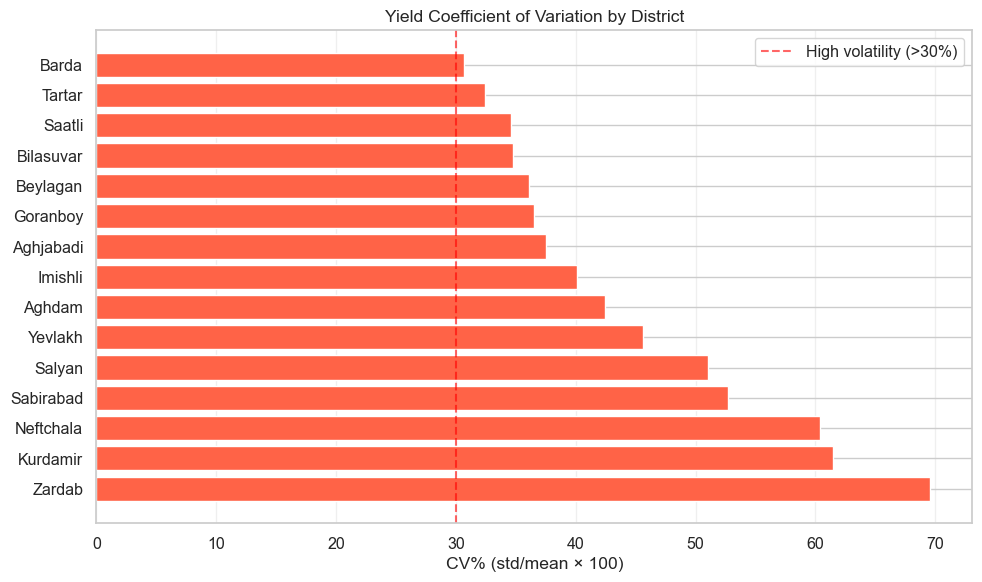

In [3]:
cv_sorted = yield_stats['cv%'].sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(10, 6))
colors = ['tomato' if v > 30 else 'steelblue' for v in cv_sorted.values]
ax.barh([r.replace(' district','') for r in cv_sorted.index],
        cv_sorted.values, color=colors)
ax.axvline(30, color='red', linestyle='--', alpha=0.6, label='High volatility (>30%)')
ax.set_title('Yield Coefficient of Variation by District')
ax.set_xlabel('CV% (std/mean × 100)')
ax.legend()
ax.grid(True, axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

## 3. Yield Anomaly Analysis

Anomaly stats:
  Mean:   1.521 (should be ~0 for training years)
  Std:    7.986
  Range:  -14.55 to 24.52


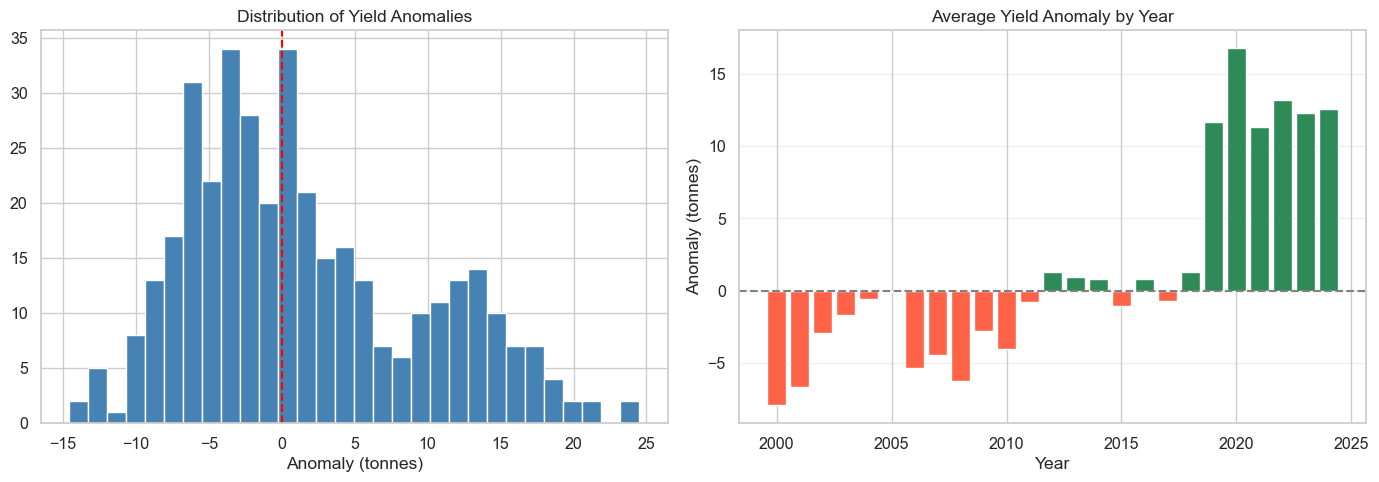

In [4]:
# Compute yield anomaly = yield - district mean
df_train = df[df['year'] <= 2021].copy()
district_mean = df_train.groupby('region')['yield_tonnes'].mean()
df['district_mean'] = df['region'].map(district_mean)
df['yield_anomaly'] = df['yield_tonnes'] - df['district_mean']

print(f'Anomaly stats:')
print(f'  Mean:   {df.yield_anomaly.mean():.3f} (should be ~0 for training years)')
print(f'  Std:    {df.yield_anomaly.std():.3f}')
print(f'  Range:  {df.yield_anomaly.min():.2f} to {df.yield_anomaly.max():.2f}')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].hist(df['yield_anomaly'], bins=30, color='steelblue', edgecolor='white')
axes[0].axvline(0, color='red', linestyle='--')
axes[0].set_title('Distribution of Yield Anomalies')
axes[0].set_xlabel('Anomaly (tonnes)')

yearly_anom = df.groupby('year')['yield_anomaly'].mean()
axes[1].bar(yearly_anom.index, yearly_anom.values,
            color=['seagreen' if v >= 0 else 'tomato' for v in yearly_anom.values])
axes[1].axhline(0, color='gray', linestyle='--')
axes[1].set_title('Average Yield Anomaly by Year')
axes[1].set_xlabel('Year')
axes[1].set_ylabel('Anomaly (tonnes)')
axes[1].grid(True, axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

## 4. Random Forest Feature Importance

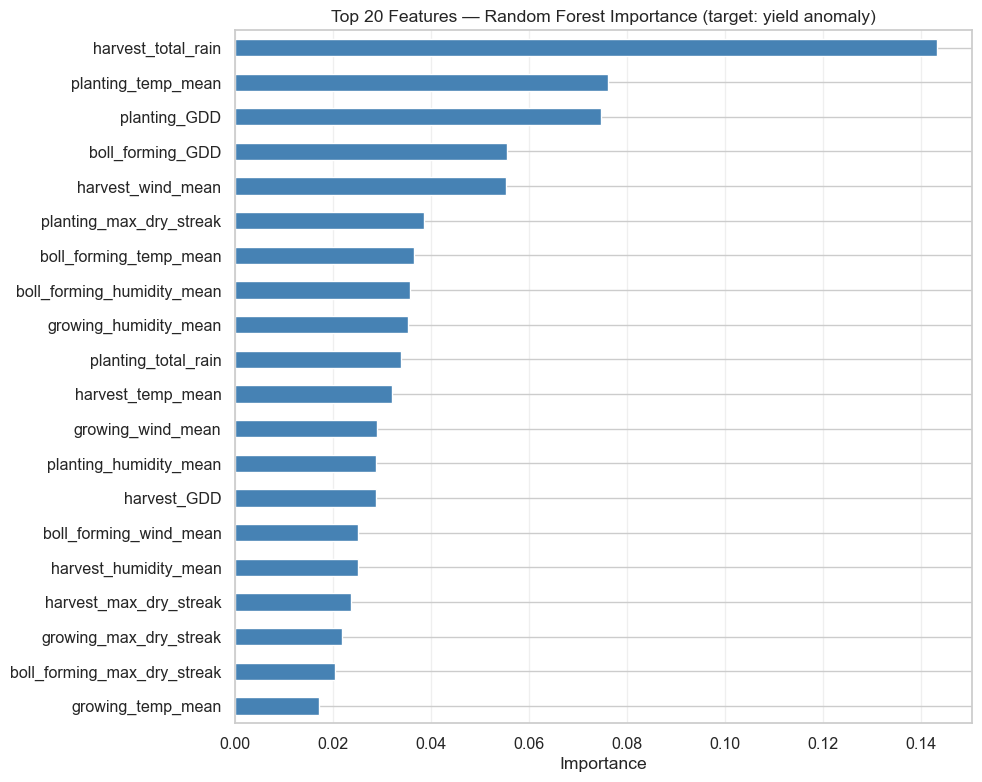

Top 5 features:
  harvest_total_rain                            0.1433
  planting_temp_mean                            0.0761
  planting_GDD                                  0.0747
  boll_forming_GDD                              0.0557
  harvest_wind_mean                             0.0553


In [5]:
exclude = {'region','weather_station','year','yield_tonnes','district_mean','yield_anomaly'}
leak_kw = ('risk','deviation','label')
feat_cols = [c for c in df.columns
             if c not in exclude and not any(k in c for k in leak_kw)]

df_tr = df[df['year'] <= 2021].dropna(subset=feat_cols + ['yield_anomaly'])

rf = RandomForestRegressor(n_estimators=200, random_state=42, n_jobs=-1)
rf.fit(df_tr[feat_cols].values, df_tr['yield_anomaly'].values)

importances = pd.Series(rf.feature_importances_, index=feat_cols)
top20 = importances.nlargest(20)

fig, ax = plt.subplots(figsize=(10, 8))
top20.sort_values().plot.barh(ax=ax, color='steelblue')
ax.set_title('Top 20 Features — Random Forest Importance (target: yield anomaly)')
ax.set_xlabel('Importance')
ax.grid(True, axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

print('Top 5 features:')
for col, imp in top20.head().items():
    print(f'  {col:<45} {imp:.4f}')

## 5. Top Feature Pairplot

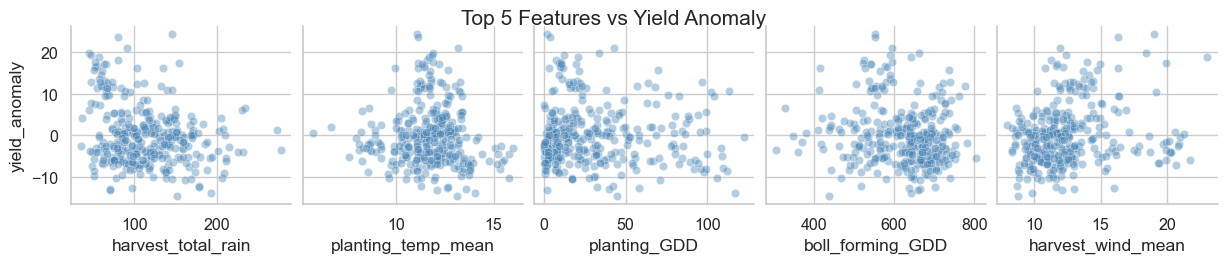

In [6]:
top5 = importances.nlargest(5).index.tolist()
df_pair = df_tr[top5 + ['yield_anomaly']].dropna()

g = sns.pairplot(df_pair, y_vars=['yield_anomaly'], x_vars=top5,
                 plot_kws={'alpha': 0.4, 'color': 'steelblue'})
g.fig.suptitle('Top 5 Features vs Yield Anomaly', y=1.02)
plt.show()

## 6. Stage-Level Mean Features

In [7]:
stages = ['planting','growing','boll_forming','harvest']
stage_summary = {}
for stage in stages:
    cols = [c for c in df.columns if c.startswith(stage + '_')]
    stage_summary[stage] = df[cols].mean().round(3)

for stage, stats in stage_summary.items():
    print(f'\n{stage.upper()} stage averages:')
    for col, val in stats.items():
        print(f'  {col:<40} {val}')

con.close()


PLANTING stage averages:
  planting_temp_mean                       11.9
  planting_heat_stress_days                0.0
  planting_frost_days                      0.325
  planting_GDD                             34.391
  planting_total_rain                      86.659
  planting_rainy_days                      16.304
  planting_dry_days                        44.144
  planting_max_dry_streak                  12.141
  planting_humidity_mean                   71.854
  planting_wind_mean                       14.392

GROWING stage averages:
  growing_temp_mean                        25.785
  growing_heat_stress_days                 5.467
  growing_frost_days                       0.0
  growing_GDD                              1268.43
  growing_total_rain                       98.251
  growing_rainy_days                       16.525
  growing_dry_days                         105.843
  growing_max_dry_streak                   42.789
  growing_humidity_mean                    55.27
  growin

## Summary
- District CV% shows moderate-to-high yield volatility ✓
- Yield anomaly centered near zero, roughly normal ✓
- Harvest rain and wind dominate feature importance ✓
- Weather explains modest year-to-year variance — district baselines dominate ✓
- **Next:** `day_08_modeling.ipynb` — model training and predictions